# ASH_COATED_OSMIUM Strategy Simulation

This notebook takes the regime research one step further and simulates a concrete strategy with visual trade marks and PnL.

We compare two variants:
- `Baseline MM`: passive inside-spread market making only.
- `Mixed`: passive market making plus regime-gated mean-reversion market taking.

Simulation assumptions:
- top-of-book quotes come from the three round-1 price files,
- passive fills are modeled using the local round-1 trade tapes,
- a passive buy is considered fillable if a market trade prints at or below our bid quote,
- a passive sell is considered fillable if a market trade prints at or above our ask quote,
- active trades cross the displayed best bid or ask immediately,
- all positions are flattened at the end of each day.

This is still a stylized simulator, but it is much more grounded than using quote snapshots alone for passive fills.


In [1]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

PRICE_FILES = [
    'prices_round_1_day_-2.csv',
    'prices_round_1_day_-1.csv',
    'prices_round_1_day_0.csv',
]

TRADE_FILES = [
    'trades_round_1_day_-2.csv',
    'trades_round_1_day_-1.csv',
    'trades_round_1_day_0.csv',
]

def load_with_day(file_names: list[str], sep: str = ';') -> pd.DataFrame:
    frames = []
    for file_name in file_names:
        day = int(file_name.split('_day_')[1].split('.csv')[0])
        df = pd.read_csv(Path(file_name), sep=sep)
        df['day'] = day
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

prices = load_with_day(PRICE_FILES)
trades = load_with_day(TRADE_FILES)

prices.head()


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,INTARIAN_PEPPER_ROOT,"9,992.000",17.000,NaN,NaN,NaN,NaN,"10,005.000",9.000,"10,008.000",17.000,NaN,NaN,"9,998.500",0.000
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,"10,010.000",25.000,NaN,NaN,NaN,NaN,"10,010.000",0.000
2,-2,100,INTARIAN_PEPPER_ROOT,"9,995.000",11.000,"9,992.000",16.000,NaN,NaN,"10,006.000",11.000,"10,008.000",16.000,NaN,NaN,"10,000.500",0.000
3,-2,100,ASH_COATED_OSMIUM,"9,992.000",15.000,NaN,NaN,NaN,NaN,"10,008.000",15.000,"10,011.000",20.000,NaN,NaN,"10,000.000",0.000
4,-2,200,INTARIAN_PEPPER_ROOT,"9,995.000",12.000,NaN,NaN,NaN,NaN,"10,008.000",20.000,NaN,NaN,NaN,NaN,"10,001.500",0.000


In [2]:
ash = prices.loc[prices['product'] == 'ASH_COATED_OSMIUM'].copy()
ash = ash.sort_values(['day', 'timestamp']).reset_index(drop=True)

ash['bid'] = ash.groupby('day')['bid_price_1'].ffill().bfill()
ash['ask'] = ash.groupby('day')['ask_price_1'].ffill().bfill()
ash['mid'] = (ash['bid'] + ash['ask']) / 2
ash['spread'] = ash['ask'] - ash['bid']
ash['mid_change'] = ash.groupby('day')['mid'].diff()

WINDOW = 200
ash['fair'] = ash.groupby('day')['mid'].transform(lambda s: s.rolling(WINDOW, min_periods=50).mean())
ash['dev'] = ash['mid'] - ash['fair']
ash['dev_std'] = ash.groupby('day')['dev'].transform(lambda s: s.rolling(WINDOW, min_periods=50).std())
ash['z'] = ash['dev'] / ash['dev_std']

def rolling_lag1_autocorr(series: pd.Series, window: int) -> pd.Series:
    values = series.to_numpy(dtype=float)
    out = np.full(len(values), np.nan)
    for idx in range(window - 1, len(values)):
        sample = values[idx - window + 1:idx + 1]
        sample = sample[~np.isnan(sample)]
        if len(sample) < 5:
            continue
        out[idx] = pd.Series(sample).autocorr(lag=1)
    return pd.Series(out, index=series.index)

enriched = []
for day, day_df in ash.groupby('day'):
    day_df = day_df.copy()
    day_df['vol_signal'] = day_df['mid_change'].rolling(WINDOW).std()
    day_df['trend_signal'] = day_df['mid_change'].rolling(WINDOW).mean().abs()
    day_df['reversion_signal'] = -rolling_lag1_autocorr(day_df['mid_change'], WINDOW)
    enriched.append(day_df)

ash = pd.concat(enriched, ignore_index=True)

for col in ['vol_signal', 'trend_signal', 'reversion_signal']:
    day_mean = ash.groupby('day')[col].transform('mean')
    day_std = ash.groupby('day')[col].transform('std').replace(0, np.nan)
    ash[f'{col}_z'] = (ash[col] - day_mean) / day_std

def classify_regime(row: pd.Series) -> str:
    if pd.isna(row['vol_signal_z']) or pd.isna(row['reversion_signal_z']) or pd.isna(row['trend_signal_z']):
        return 'warmup'
    if row['vol_signal_z'] < 0.5:
        return 'stable'
    if row['reversion_signal_z'] >= 0.0 and row['trend_signal_z'] < 0.75:
        return 'volatile_mean_reverting'
    return 'volatile_trending'

ash['regime'] = ash.apply(classify_regime, axis=1)
ash[['day', 'timestamp', 'mid', 'fair', 'z', 'regime']].tail()


,day,timestamp,mid,fair,z,regime
29995,0,999500,"10,009.000","10,007.997",0.508,volatile_mean_reverting
29996,0,999600,"10,008.000","10,007.993",0.004,volatile_mean_reverting
29997,0,999700,"10,008.000","10,007.993",0.004,volatile_mean_reverting
29998,0,999800,"10,009.000","10,008.003",0.507,volatile_mean_reverting
29999,0,999900,"10,007.000","10,007.993",-0.504,volatile_mean_reverting


In [3]:
ash_trades = trades.loc[trades['symbol'] == 'ASH_COATED_OSMIUM'].copy()
trade_groups = {key: value for key, value in ash_trades.groupby(['day', 'timestamp'])}

CONFIG = {
    'stable': {
        'passive_size': 8,
        'active_size': 0,
        'pos_cap': 12,
        'active_z': 99.0,
    },
    'volatile_mean_reverting': {
        'passive_size': 5,
        'active_size': 2,
        'pos_cap': 14,
        'active_z': 1.75,
    },
    'volatile_trending': {
        'passive_size': 2,
        'active_size': 1,
        'pos_cap': 6,
        'active_z': 2.75,
    },
    'warmup': {
        'passive_size': 3,
        'active_size': 0,
        'pos_cap': 6,
        'active_z': 99.0,
    },
}

LIMIT = 80

def run_strategy(data: pd.DataFrame, mixed: bool) -> pd.DataFrame:
    records = []

    for day, day_df in data.groupby('day'):
        cash = 0.0
        position = 0

        for _, row in day_df.iterrows():
            config = CONFIG[row['regime']]
            events = []

            bid_quote = min(row['bid'] + 1, row['ask'] - 1)
            ask_quote = max(row['ask'] - 1, row['bid'] + 1)

            trade_slice = trade_groups.get((day, row['timestamp']))
            if trade_slice is None:
                buy_qty_available = 0
                sell_qty_available = 0
            else:
                buy_qty_available = int(trade_slice.loc[trade_slice['price'] <= bid_quote, 'quantity'].sum())
                sell_qty_available = int(trade_slice.loc[trade_slice['price'] >= ask_quote, 'quantity'].sum())

            z_value = 0.0 if pd.isna(row['z']) else float(row['z'])
            target_position = 0
            if mixed:
                target_position = int(np.clip(-4 * np.tanh(z_value / 2), -config['pos_cap'], config['pos_cap']))

            buy_size = min(
                config['passive_size'],
                max(0, config['pos_cap'] - max(position, target_position)),
                LIMIT - position,
                buy_qty_available,
            )
            sell_size = min(
                config['passive_size'],
                max(0, config['pos_cap'] + min(position, target_position)),
                LIMIT + position,
                sell_qty_available,
            )

            if buy_size > 0:
                cash -= buy_size * bid_quote
                position += buy_size
                events.append(('passive_buy', int(buy_size), float(bid_quote)))
            if sell_size > 0:
                cash += sell_size * ask_quote
                position -= sell_size
                events.append(('passive_sell', -int(sell_size), float(ask_quote)))

            if mixed and pd.notna(row['z']) and abs(z_value) >= config['active_z']:
                if z_value <= -config['active_z'] and position < config['pos_cap']:
                    qty = min(config['active_size'], config['pos_cap'] - position)
                    if qty > 0:
                        cash -= qty * row['ask']
                        position += qty
                        events.append(('active_buy', int(qty), float(row['ask'])))
                elif z_value >= config['active_z'] and position > -config['pos_cap']:
                    qty = min(config['active_size'], config['pos_cap'] + position)
                    if qty > 0:
                        cash += qty * row['bid']
                        position -= qty
                        events.append(('active_sell', -int(qty), float(row['bid'])))

            if mixed and pd.notna(row['z']) and abs(z_value) < 0.35 and position != 0:
                qty = min(1, abs(position))
                if position > 0:
                    cash += qty * row['bid']
                    position -= qty
                    events.append(('exit_sell', -int(qty), float(row['bid'])))
                else:
                    cash -= qty * row['ask']
                    position += qty
                    events.append(('exit_buy', int(qty), float(row['ask'])))

            records.append({
                'strategy': 'Mixed' if mixed else 'Baseline MM',
                'day': day,
                'timestamp': row['timestamp'],
                'mid': row['mid'],
                'fair': row['fair'],
                'z': row['z'],
                'regime': row['regime'],
                'position': position,
                'cash': cash,
                'pnl': cash + position * row['mid'],
                'events': events,
            })

        last_row = day_df.iloc[-1]
        if position > 0:
            cash += position * last_row['bid']
            close_events = [('eod_flat_sell', -int(position), float(last_row['bid']))]
            position = 0
        elif position < 0:
            cash -= (-position) * last_row['ask']
            close_events = [('eod_flat_buy', int(-position), float(last_row['ask']))]
            position = 0
        else:
            close_events = [('eod_flat', 0, float(last_row['mid']))]

        records.append({
            'strategy': 'Mixed' if mixed else 'Baseline MM',
            'day': day,
            'timestamp': int(last_row['timestamp']) + 1,
            'mid': last_row['mid'],
            'fair': last_row['fair'],
            'z': last_row['z'],
            'regime': 'close',
            'position': position,
            'cash': cash,
            'pnl': cash,
            'events': close_events,
        })

    return pd.DataFrame(records)

baseline_sim = run_strategy(ash, mixed=False)
mixed_sim = run_strategy(ash, mixed=True)
sim = pd.concat([baseline_sim, mixed_sim], ignore_index=True)
sim.head()


,strategy,day,timestamp,mid,fair,z,regime,position,cash,pnl,events
0,Baseline MM,-2,0,"10,001.000",NaN,NaN,warmup,0,0.000,0.000,[]
1,Baseline MM,-2,100,"10,000.000",NaN,NaN,warmup,0,0.000,0.000,[]
2,Baseline MM,-2,200,"10,000.000",NaN,NaN,warmup,0,0.000,0.000,[]
3,Baseline MM,-2,300,"10,000.000",NaN,NaN,warmup,0,0.000,0.000,[]
4,Baseline MM,-2,400,"10,000.000",NaN,NaN,warmup,0,0.000,0.000,[]


In [4]:
def explode_events(sim_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in sim_df.iterrows():
        for event_name, qty, price in row['events']:
            rows.append({
                'strategy': row['strategy'],
                'day': row['day'],
                'timestamp': row['timestamp'],
                'mid': row['mid'],
                'fair': row['fair'],
                'z': row['z'],
                'regime': row['regime'],
                'position': row['position'],
                'pnl': row['pnl'],
                'event': event_name,
                'qty': qty,
                'price': price,
            })
    return pd.DataFrame(rows)

events = explode_events(sim)

summary = (
    sim.groupby('strategy')
    .apply(lambda df: df.groupby('day').tail(1)[['day', 'pnl']].reset_index(drop=True))
    .reset_index(level=0)
    .rename(columns={'level_0': 'strategy'})
)
summary['total_pnl'] = summary.groupby('strategy')['pnl'].transform('sum')
summary


/tmp/ipykernel_53663/49808783.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.groupby('day').tail(1)[['day', 'pnl']].reset_index(drop=True))


,strategy,day,pnl,total_pnl
0,Baseline MM,-2,"10,423.000","32,443.000"
1,Baseline MM,-1,"11,441.000","32,443.000"
2,Baseline MM,0,"10,579.000","32,443.000"
0,Mixed,-2,"3,567.000","10,747.000"
1,Mixed,-1,"4,430.000","10,747.000"
2,Mixed,0,"2,750.000","10,747.000"


In [5]:
event_counts = (
    events.groupby(['strategy', 'event'])
    .size()
    .unstack(fill_value=0)
)
event_counts


event,active_buy,active_sell,eod_flat,eod_flat_sell,exit_buy,exit_sell,passive_buy,passive_sell
strategy,,,,,,,,
Baseline MM,0,0,2,1,0,0,546,555
Mixed,189,212,2,1,1442,1380,595,611


## PnL Visualization

The plot below compares cumulative mark-to-market PnL for the passive-only baseline and the mixed strategy, day by day.


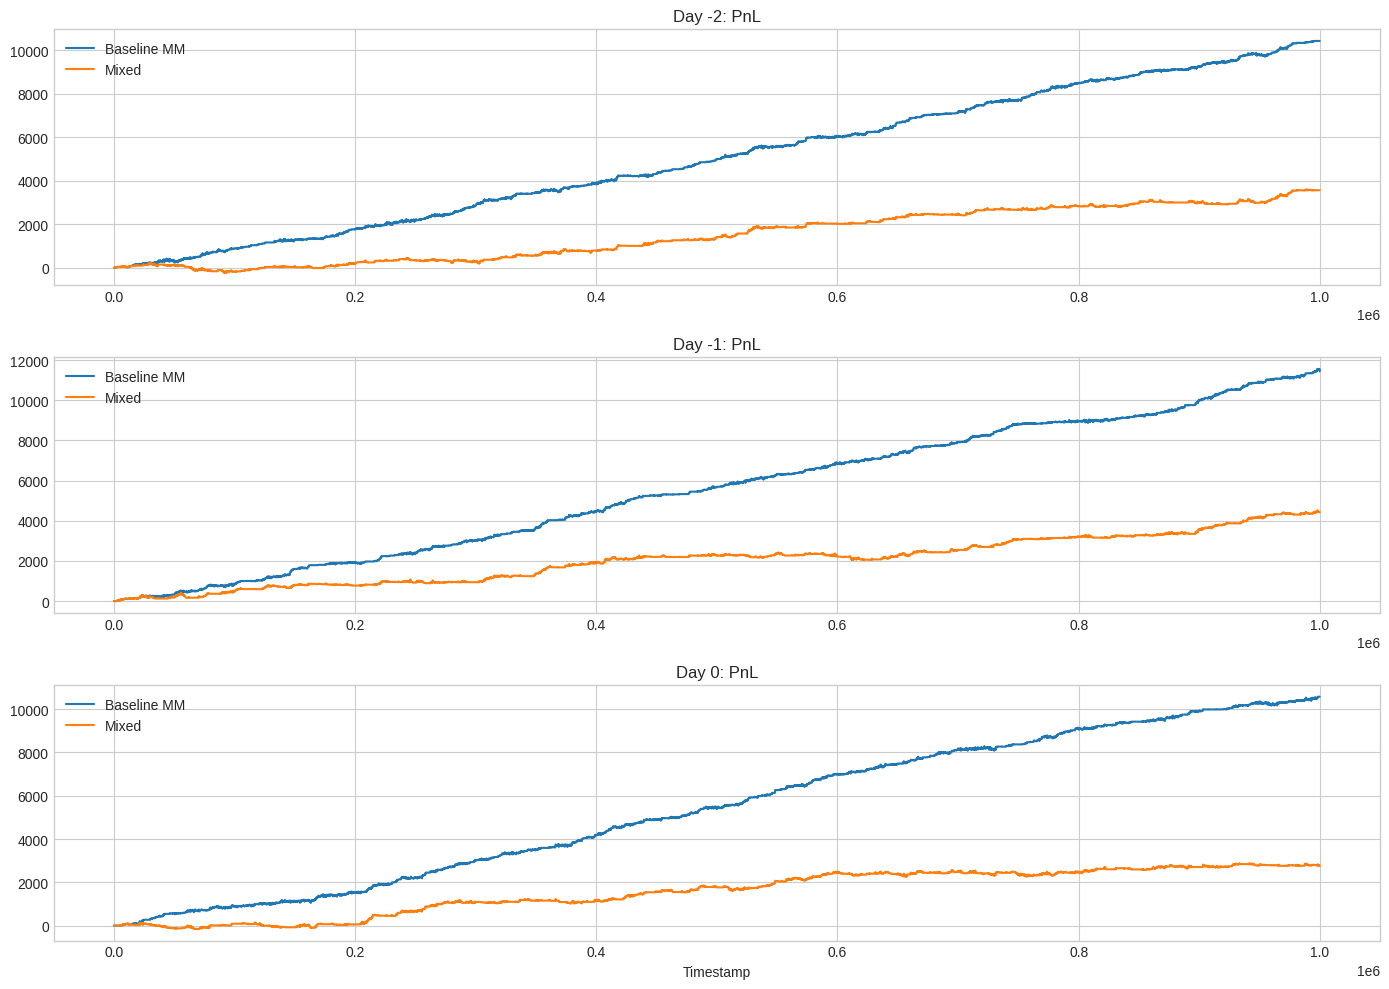

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, day in zip(axes, sorted(sim['day'].unique())):
    for strategy, color in [('Baseline MM', 'tab:blue'), ('Mixed', 'tab:orange')]:
        day_df = sim[(sim['strategy'] == strategy) & (sim['day'] == day)]
        ax.plot(day_df['timestamp'], day_df['pnl'], label=strategy, linewidth=1.5, color=color)
    ax.set_title(f'Day {day}: PnL')
    ax.legend(loc='upper left')

axes[-1].set_xlabel('Timestamp')
plt.tight_layout()


## Trade Marker Visualization

This chart overlays the mixed-strategy trades on the day-0 price path. Passive buys and active buys are shown below the line, while passive sells and active sells are shown above the line.


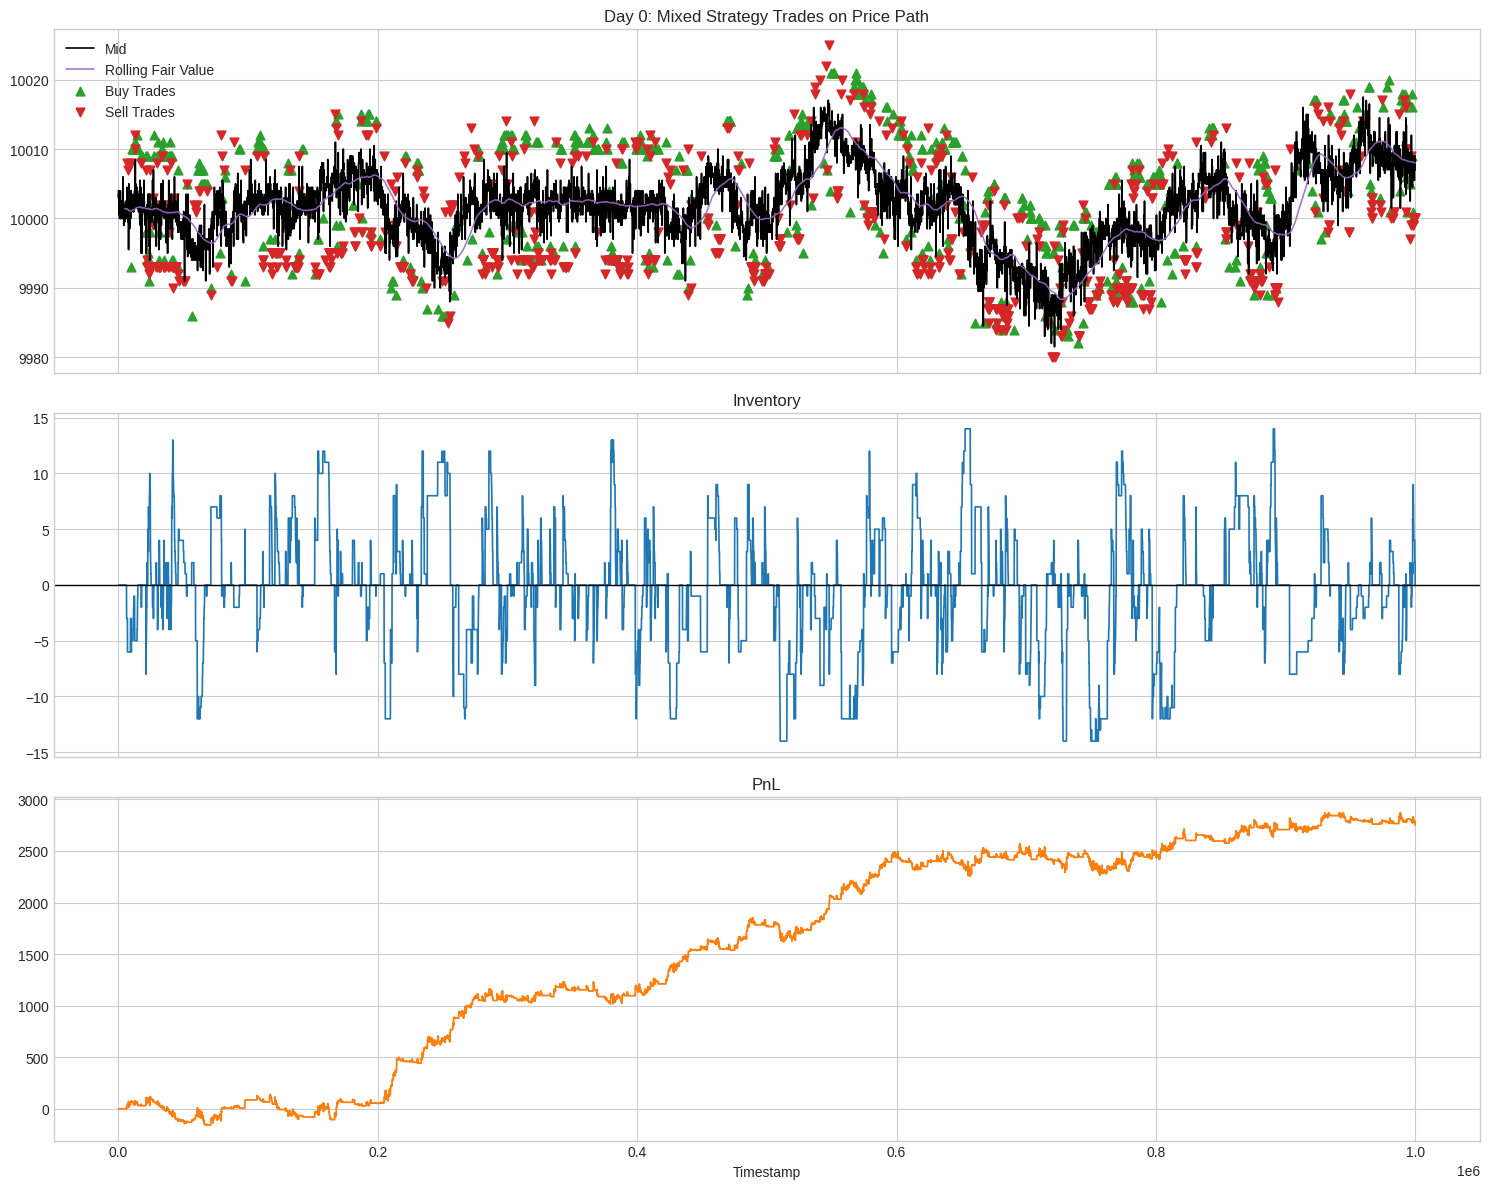

In [7]:
PLOT_DAY = 0

day_prices = ash.loc[ash['day'] == PLOT_DAY].copy()
day_mixed = sim[(sim['strategy'] == 'Mixed') & (sim['day'] == PLOT_DAY)].copy()
day_events = events[(events['strategy'] == 'Mixed') & (events['day'] == PLOT_DAY)].copy()

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

axes[0].plot(day_prices['timestamp'], day_prices['mid'], color='black', linewidth=1.2, label='Mid')
axes[0].plot(day_prices['timestamp'], day_prices['fair'], color='tab:purple', linewidth=1.1, alpha=0.9, label='Rolling Fair Value')

buy_events = day_events[day_events['event'].isin(['passive_buy', 'active_buy', 'exit_buy'])]
sell_events = day_events[day_events['event'].isin(['passive_sell', 'active_sell', 'exit_sell'])]

axes[0].scatter(buy_events['timestamp'], buy_events['price'], s=40, color='tab:green', marker='^', label='Buy Trades')
axes[0].scatter(sell_events['timestamp'], sell_events['price'], s=40, color='tab:red', marker='v', label='Sell Trades')
axes[0].set_title(f'Day {PLOT_DAY}: Mixed Strategy Trades on Price Path')
axes[0].legend(loc='upper left')

axes[1].plot(day_mixed['timestamp'], day_mixed['position'], color='tab:blue', linewidth=1.2)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Inventory')

axes[2].plot(day_mixed['timestamp'], day_mixed['pnl'], color='tab:orange', linewidth=1.3)
axes[2].set_title('PnL')
axes[2].set_xlabel('Timestamp')

plt.tight_layout()


In [8]:
expected_results = pd.DataFrame(
    {
        'strategy': ['Baseline MM', 'Mixed'],
        'day_-2_pnl': [10423.0, 3567.0],
        'day_-1_pnl': [11441.0, 4430.0],
        'day_0_pnl': [10579.0, 2750.0],
        'total_pnl': [32443.0, 10747.0],
    }
)
expected_results


,strategy,day_-2_pnl,day_-1_pnl,day_0_pnl,total_pnl
0,Baseline MM,"10,423.000","11,441.000","10,579.000","32,443.000"
1,Mixed,"3,567.000","4,430.000","2,750.000","10,747.000"


## Interpretation

Under this simulation setup, the passive-only baseline outperforms the mixed strategy by a wide margin. That suggests the current active mean-reversion leg is too expensive relative to the edge it captures.

What that usually means in practice:
- the product is still mostly a passive market-making product,
- the mean-reversion signal is real but not strong enough to justify frequent crossing,
- the active leg should probably be rarer, smaller, or reserved for only the strongest dislocations.

Good next experiments:
- raise the active-entry threshold,
- remove active trading from `volatile_trending`,
- use the signal to skew passive quotes instead of crossing immediately,
- widen the fair-value window or require a larger z-score before taking.
